<a href="https://colab.research.google.com/github/lassenilssonnn/digital-legal-studies-python/blob/main/Lesson_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 10: Evidence, Prediction, and the Machines

## The Final Class of Digital Legal Studies

Welcome to the last class.

Over the past weeks, you have gone from `print("Welcome to Digital Legal Science.")` to building machine learning classifiers, computing Bayesian updates on real legal data, and comparing algorithmic predictions to judicial decisions (or at least seeing me do it).

Today we tie it all together:

1. **Bayesian reasoning** — what it actually is (explained a bit better, hehe), why it matters, and how it connects to being a better lawyer
2. **Model vs. judges** — the hard normative questions we left open last week
3. **Large Language Models** — what they are, what breaks, and what it means for you
4. **Closing** — what you now know that most lawyers do not

### Pre-reading

You should have read or skimmed the **Mata v. Avianca** opinion. Quick summary if you haven't:

A lawyer named Steven Schwartz used ChatGPT to research a legal brief. ChatGPT fabricated six judicial opinions complete with realistic case names, citations, docket numbers, and legal reasoning. Schwartz cited these fake cases without verifying them. When the court and opposing counsel couldn't find the cases, Schwartz didn't come clean, instead he doubled down and submitted excerpts of the fake opinions (also from ChatGPT), and even asked ChatGPT whether its own cases were real. Can you guess what the ever affirmative ChatGPT said?

The court sanctioned both lawyers and their firm. The judge found bad faith; not for using AI, but for failing to verify-- for failing to update beliefs (my words, obviously not his), and misleading the court.

Keep this case in mind. We will come back to it.



## Submitting Notebooks

Remember, you need to submit these notebooks through Moodle:

1. Access the notebook on Moodle ✅
2. Complete the exercises
3. Save as PDF (File → Print → Save as PDF)
4. Upload to Moodle under the correct notebook name

## Final assignment

I have extended the deadline to the 20th of April. I will not give more extensions.


### Drinks today: Why We follow Rules (and their instructor and me)

Anežka (Anežská 812/12, Prague 1) from 7:00 p.m. onwards.



# Part 1: Bayesian Reasoning — What It Is and Why It Matters

## The Technical Version

Last week we learned Bayes' rule:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

In plain language: **start with a prior belief. Then update it when new evidence appears.**

The key insight: **evidence only matters if it is rare.** If the evidence is common anyway, it tells us very little.

That is the math. But there is a deeper idea here.

## The Deeper Idea: Scouts and Soldiers

Julia Galef, in her book *The Scout Mindset*, makes a distinction about ways that we reason that is very useful for lawyers.

A **soldier** defends a position. Their goal is to win. They look for evidence that supports their side and dismiss evidence that doesn't.

A **scout** tries to see the world clearly. Their goal is to form an accurate picture of reality. They update their beliefs when they encounter new evidence — even evidence they don't like.

Bayesian reasoning is the scout mindset, formalized.

Now, here is the connection to law: **you will often be a soldier.** That is your job. You defend your client. You construct the strongest possible argument.

But **the best soldiers are also scouts.** Why?

Because if you see the world clearly, you can:
- **Foresee opposing counsel's arguments.** The probability that your client is guilty isn't 0%. What is the base rate of murder suspects who are actually convicted? Of fraud cases that succeed? If you refuse to consider that probability, you will be blindsided. -- Pick your clients well!
- **Evaluate evidence honestly.** Your client's friend says he's a good person. Is that something you should update your prior on? How common is it for friends to say nice things about defendants? (Very common. So it is weak evidence.)
- **Avoid catastrophic errors.** Schwartz in the Mata v. Avianca case had evidence that something was wrong — he couldn't find "Varghese" in any database. But his prior belief that "ChatGPT can't fabricate cases" was so strong that he didn't update. A scout would have updated.

**Thinking in probabilities makes you humble.** And humility makes you better at your job — whether that job is activism or law.

## Now Let's Make It Concrete

Two examples that will make it stick

## Example 1: The Drug Test Problem

> A drug test is **99% accurate:**
> - If someone uses drugs, the test identifies them 99% of the time.
> - If someone does NOT use drugs, the test clears them 99% of the time.
>
> In the population being tested, **2% of people actually use drugs.**
>
> A person tests positive. **What is the probability they actually use drugs?**

### Gut estimate — what do you think?

Write it here:

(And don't be afraid to tell me when I ask you :-D )

In [11]:
# =========================================================
# THE DRUG TEST PROBLEM
# =========================================================

population = 10000
base_rate = 0.02
actual_users = int(population * base_rate)
non_users = population - actual_users

sensitivity = 0.99
false_positive_rate = 0.01

true_positives = int(actual_users * sensitivity)
false_positives = int(non_users * false_positive_rate)
total_positives = true_positives + false_positives

probability = true_positives / total_positives

print(f"Population: {population:,}")
print(f"Actual drug users: {actual_users}")
print(f"Non-users: {non_users:,}")
print()
print(f"True positives (users correctly identified): {true_positives}")
print(f"False positives (non-users incorrectly flagged): {false_positives}")
print(f"Total positive tests: {total_positives}")
print()
print(f"P(actually a user | positive test) = {probability:.1%}")
print()
print("Not 99%. Not even close.")
print()
print(f"Only {base_rate:.0%} of people use drugs.")
print(f"The {non_users:,} non-users produce {false_positives} false positives --")
print(f"almost as many as the {true_positives} true positives.")

Population: 10,000
Actual drug users: 200
Non-users: 9,800

True positives (users correctly identified): 198
False positives (non-users incorrectly flagged): 98
Total positive tests: 296

P(actually a user | positive test) = 66.9%

Not 99%. Not even close.

Only 2% of people use drugs.
The 9,800 non-users produce 98 false positives --
almost as many as the 198 true positives.


### What happens if we change the base rate?

Base Rate -> P(user | positive test)
------------------------------------------
    0.1%    ->    9.0%
    0.5%    ->    33.2%
    1.0%    ->    50.0%
    2.0%    ->    66.9%
    5.0%    ->    83.9%
   10.0%    ->    91.7%
   20.0%    ->    96.1%
   50.0%    ->    99.0%


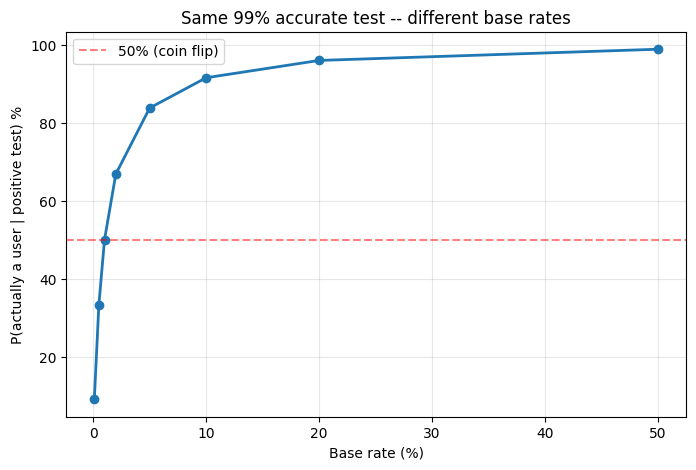

In [1]:
# =========================================================
# HOW THE BASE RATE CHANGES EVERYTHING
# =========================================================

import matplotlib.pyplot as plt

base_rates = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50]
posterior_probs = []
population = 100000

print("Base Rate -> P(user | positive test)")
print("-" * 42)

for br in base_rates:
    users = population * br
    non_users = population * (1 - br)
    tp = users * 0.99
    fp = non_users * 0.01
    posterior = tp / (tp + fp)
    posterior_probs.append(posterior)
    print(f"  {br:6.1%}    ->    {posterior:.1%}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([br * 100 for br in base_rates], [p * 100 for p in posterior_probs], marker='o', linewidth=2)
ax.set_xlabel("Base rate (%)")
ax.set_ylabel("P(actually a user | positive test) %")
ax.set_title("Same 99% accurate test -- different base rates")
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (coin flip)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### The Prosecutor’s Fallacy

This mistake has a name in law: **the prosecutor’s fallacy**.
It involves confusing two different probabilities:

* **P(positive test | innocent)** — how often the test falsely flags an innocent person
* **P(innocent | positive test)** — how likely a person is innocent given a positive result

These are not the same.

The direction matters. One conditions on innocence; the other conditions on the evidence. To move from the first to the second, we need the **base rate** — how many innocent and guilty people there are to begin with.

If the underlying condition is rare, most people are innocent. Even a small false-positive rate, applied to a large group of innocent people, produces many false positives. As a result, among all positive results, a substantial share can come from innocent individuals.

A low false-positive rate does not, by itself, mean that a person who tested positive is probably guilty. The meaning of a positive result depends not only on the test, but on how rare the underlying condition is.

### O.J. Simpson: Base Rates in Opposite Directions

Both sides made base-rate errors.

**Prosecution:**
A blood match shared by 1 in 400 people sounds strong. But in a city the size of Los Angeles, that still corresponds to thousands of potential matches. A match alone is weak evidence if many people match.

**Defense:**
Only 1 in 2,500 abused women are murdered by their abuser. This sounds like the abuse history is irrelevant—but it answers the wrong question.

The relevant question is:

> **Given that a battered woman has been murdered, what is the probability that her batterer did it?**

The answer is much higher (around 90%), because most such murders are committed by the batterer.

---

### The Core Error

* (P(\text{batterer killed her} \mid \text{she was battered})) ≈ 1 in 2,500
* (P(\text{batterer killed her} \mid \text{she was battered AND murdered})) ≈ 90%

Both sides failed to condition on the right base rate.

**Same mistake, opposite directions.**


## Example 2: The Forensic Match

In [ ]:
# =========================================================
# THE FORENSIC MATCH PROBLEM
# =========================================================

city_population = 1_000_000
match_rate = 1 / 10_000

print(f"City population: {city_population:,}")
print(f"Forensic match rate: 1 in {int(1/match_rate):,}")
print(f"Expected false matches: {int(city_population * match_rate)}")
print()
print("A 'match' identifies 100 candidates, not 1 guilty person.")

In [ ]:
# =========================================================
# THE PRIOR CHANGES EVERYTHING
# =========================================================

p_match_guilty = 1.0
p_match_innocent = 1 / 10_000

scenarios = [
    ("Random person from city", 1 / 1_000_000),
    ("Narrowed to 100 suspects", 1 / 100),
    ("Strong independent evidence", 1 / 5),
]

print("Same forensic match (1 in 10,000). Different priors.")
print("=" * 60)

for name, prior in scenarios:
    p_match = p_match_guilty * prior + p_match_innocent * (1 - prior)
    posterior = (p_match_guilty * prior) / p_match
    print(f"{name} (prior = {prior:.6f}):")
    print(f"  P(guilty | match) = {posterior:.2%}")
    print()

print("The SAME evidence. Completely different conclusions.")
print("The prior changes everything.")

In [15]:
# =========================================================
# EXERCISE: YOUR CLIENT'S ALIBI
# =========================================================
# Your client is accused of fraud.
# A witness says they saw your client at the crime scene.
#
# But: how reliable is the witness?
# And: what was the prior probability your client did it?
#
# Play with these numbers and see what happens.

# YOUR INPUTS (change these!)
prior_guilty = 0.05          # before the witness, how likely is guilt?
p_witness_if_guilty = 0.90   # if guilty, how likely would the witness see them?
p_witness_if_innocent = 0.15 # if innocent, how likely is a false sighting?

# BAYES' RULE
p_witness = (p_witness_if_guilty * prior_guilty) + (p_witness_if_innocent * (1 - prior_guilty))
posterior_guilty = (p_witness_if_guilty * prior_guilty) / p_witness

print(f"Prior probability of guilt: {prior_guilty:.1%}")
print(f"Witness reliability (if guilty): {p_witness_if_guilty:.1%}")
print(f"False sighting rate (if innocent): {p_witness_if_innocent:.1%}")
print()
print(f"POSTERIOR probability of guilt: {posterior_guilty:.1%}")
print()
print("Now try changing the numbers:")
print("- What if the prior is 50%?")
print("- What if the witness is only 60% reliable?")
print("- What if false sightings are very common (40%)?")
print()
print("Notice: the same witness testimony means very different")
print("things depending on the prior and the false sighting rate.")

Prior probability of guilt: 5.0%
Witness reliability (if guilty): 90.0%
False sighting rate (if innocent): 15.0%

POSTERIOR probability of guilt: 24.0%

Now try changing the numbers:
- What if the prior is 50%?
- What if the witness is only 60% reliable?
- What if false sightings are very common (40%)?

Notice: the same witness testimony means very different
things depending on the prior and the false sighting rate.


### Connecting Back

Remember the calibration quiz? You were overconfident. Same failure mode as the prosecutor's fallacy.

Remember the Matthew exercise? Most people said "English professor" because the description *sounded* right. But ~3.5 million truck drivers vs ~100,000 English professors. The base rate overwhelms the description.

**Being willing to update is a skill, not a weakness.** The best lawyers can simultaneously advocate fiercely for their client AND privately hold an honest assessment of the probabilities.

# Part 2: Model vs. Judges — The Normative Gap

Last week's key numbers:

| | Model | Judges |
|---|---|---|
| **Accuracy** | 79.6% | 64.5% |
| **AUC** | 0.686 | 0.449 |
| **True positives** | 384 | 912 |
| **False positives** | 531 | 6,674 |

The model is better at **predicting** rearrest. But prediction is not decision.

**Three tensions:**

1. **False positive tradeoff.** How many wrongful detentions per correct prediction is acceptable?
2. **Threshold problem.** At what probability do you detain? Legal standards deliberately leave this qualitative.
3. **Feedback loop.** Detain everyone flagged → never observe the counterfactual → model can never be proven wrong.

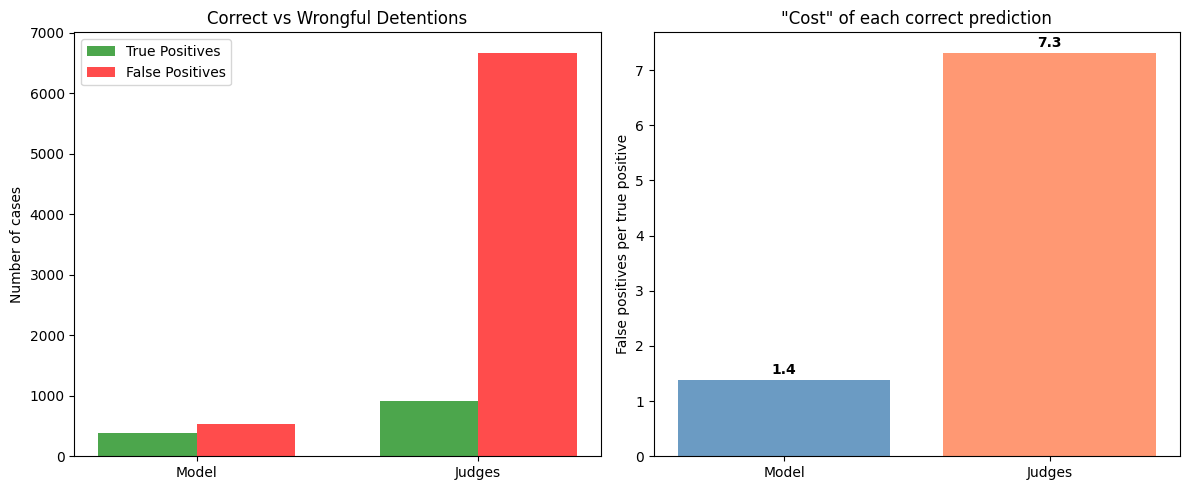

Model: 1.4 wrongful detentions per correct prediction
Judges: 7.3 wrongful detentions per correct prediction

Is efficiency the right metric? This is a legal question, not a statistical one.


In [2]:
# =========================================================
# THE TRADEOFF: VISUALIZED
# =========================================================

import matplotlib.pyplot as plt

labels = ['Model', 'Judges']
true_pos = [384, 912]
false_pos = [531, 6674]
ratios = [fp/tp for fp, tp in zip(false_pos, true_pos)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = range(len(labels))
width = 0.35
axes[0].bar([i - width/2 for i in x], true_pos, width, label='True Positives', color='green', alpha=0.7)
axes[0].bar([i + width/2 for i in x], false_pos, width, label='False Positives', color='red', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Number of cases')
axes[0].set_title('Correct vs Wrongful Detentions')
axes[0].legend()

axes[1].bar(labels, ratios, color=['steelblue', 'coral'], alpha=0.8)
axes[1].set_ylabel('False positives per true positive')
axes[1].set_title('"Cost" of each correct prediction')
for i, v in enumerate(ratios):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Model: {ratios[0]:.1f} wrongful detentions per correct prediction")
print(f"Judges: {ratios[1]:.1f} wrongful detentions per correct prediction")
print()
print("Is efficiency the right metric? This is a legal question, not a statistical one.")

# Part 3: Large Language Models

## What is an LLM?

We've built a built a logistic regression (which reduces the error), i'll draw an example. You gave it features (variables) It learned patterns. It predicted.

An LLM does the same — at vastly greater scale, with **language** as both input and output. It predicts the **next word** given everything before it. That is the entire mechanism.

It is not a search engine. Not a database. Not a reasoning engine. It is a **pattern completion machine.**

## Why This Matters for You

You are beginner coders. Unlike most coders, you still have your jobs. That is because you have **domain expertise in law.**

Schwartz from Mata v. Avianca practiced exclusively in state courts. He had never dealt with the Montreal Convention or federal bankruptcy stays. He was outside his domain and used a tool he didn't understand. The court said: *"there is nothing inherently improper about using a reliable artificial intelligence tool for assistance."* The problem was that he didn't understand what the tool was.

You now know the difference.

## The Future of Law and AI

Frank Fagan (*"A View of How Language Models Will Transform Law," 92 Tennessee Law Review 1-86, 2025*) argues:

**Near term:** LLMs create **new** legal work — property rights in data, new torts from lightly supervised AI use.

**Medium term:** Routine tasks done by LLMs, lawyers supervise. A 10% productivity increase would let a large firm cut 300-400 associates — saving $60-120 million.

**Long term:** Lawyers pushed into roles requiring **value judgments and empathy** — developing precedent, allocating resources, navigating nuance.

You don't need to be a software engineer. You need to be a **lawyer who understands the tools.**

In [12]:
# =========================================================
# LLM HALLUCINATION AS A BASE-RATE PROBLEM
# =========================================================

hallucination_rates = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]
n_citations = 6

print(f"You ask an LLM for {n_citations} case citations.")
print(f"Each has some probability of being fabricated.")
print()
print(f"{'Hallucination rate':>20} | {'P(all 6 real)':>15} | {'P(>=1 fake)':>15}")
print("-" * 58)

for rate in hallucination_rates:
    p_all_real = (1 - rate) ** n_citations
    p_at_least_one_fake = 1 - p_all_real
    print(f"{rate:>19.0%}  | {p_all_real:>14.1%}  | {p_at_least_one_fake:>14.1%}")

print()
print("Even a 5% hallucination rate means ~26% chance")
print("that at least one of your 6 citations is fake.")
print()
print("This is why verification is not optional.")

You ask an LLM for 6 case citations.
Each has some probability of being fabricated.

  Hallucination rate |   P(all 6 real) |     P(>=1 fake)
----------------------------------------------------------
                 1%  |          94.1%  |           5.9%
                 5%  |          73.5%  |          26.5%
                10%  |          53.1%  |          46.9%
                20%  |          26.2%  |          73.8%
                30%  |          11.8%  |          88.2%
                50%  |           1.6%  |          98.4%

Even a 5% hallucination rate means ~26% chance
that at least one of your 6 citations is fake.

This is why verification is not optional.


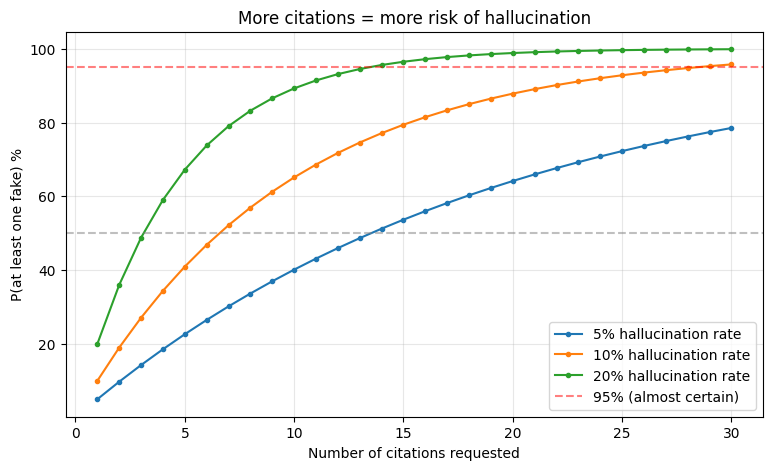

The more you rely on unverified output,
the more likely you are to get burned.


In [13]:
# =========================================================
# HOW MANY CITATIONS BEFORE A FAKE IS ALMOST CERTAIN?
# =========================================================

import matplotlib.pyplot as plt

n_range = range(1, 31)
rates_to_plot = [0.05, 0.10, 0.20]

fig, ax = plt.subplots(figsize=(9, 5))
for rate in rates_to_plot:
    probs = [1 - (1 - rate)**n for n in n_range]
    ax.plot(list(n_range), [p * 100 for p in probs], marker='.', label=f'{rate:.0%} hallucination rate')

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% (almost certain)')
ax.set_xlabel('Number of citations requested')
ax.set_ylabel('P(at least one fake) %')
ax.set_title('More citations = more risk of hallucination')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("The more you rely on unverified output,")
print("the more likely you are to get burned.")

## Mata v. Avianca: The Failures Connected

1. **Misunderstanding the tool.** He thought it was a search engine. It is a pattern completion machine.
2. **Bayesian failure.** He had evidence the cases didn't exist. He didn't update.
3. **Hallucination as base-rate problem.** Sounds reliable, but the base rate of fabricated content means you must verify.
4. **Circular verification.** He asked ChatGPT if its own cases were real. Like asking the drug test to confirm its own result.
5. **Accountability gap.** With your logistic regression, you could inspect coefficients. With an LLM, reasoning is opaque.

# Part 4: Closing the Course

## You Do Not Need to Memorize Anything

The law is not about memorizing statutes: it is about knowing where to find them, how to read them, and how to apply them.

Coding works the same way.

Like good old Mr Schwartz, who was working outside of his domain and used AI and got in quite a bit of trouble, you will also work outside your domain.

But now you know there are tools. There is documentation — remember Lesson 2, when we used the `math` module by looking at its docs? There are libraries. There is AI — and you know what it actually is, and you know to verify.


## What You Now Know That Most Lawyers Do Not

- Intermediate coding skills -- Graphing, statistics, data science
- Base-rate neglect and the prosecutor's fallacy (Bayesian reasoning)
- Machine learning, what is it, how do machines learn, what do they do?
- Graphing and looking at cases:

This is a **governance competence.** AI is going to become more common in law. The lawyers who understand these tools will thrive. The ones who don't will be explaining to Judge Castel why their citations don't exist.




In Lesson 1, you printed `"Welcome to Digital Legal Science."`

In Lesson 10, you can explain why a 99% accurate test might be wrong two-thirds of the time, why the same evidence means different things depending on your prior, why a machine learning model can outperform judges at prediction but not at justice, how to make code, where to find documentation on how to write code, graph your findings, say true things about law.

That is a lot to learn in one semester, Well done!

See you around.